# 定理22　高高度 LUB 臨場感定理 — 階段（LUB の列）の数値例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理22は何を言っているのか

### 原文の主張

心の「考えの高さ（抽象度）」を、**包含で順序づけられた世界** の束で表します。新しい情報・他者の視点 $v_{n+1}$ を得たとき、**古い世界を消さずに包む**（結合 $\vee$）更新を考えます。

$$
u_{n+1}=u_n\vee v_{n+1}\qquad(22.1)
$$

$u_n$ は段 $n$ の世界（LUB）。$\vee$ は「両方を含む最小の世界」を作る操作です。

* **(22.3) 厳密上昇：** 新情報が **すでに含まれていない**（$v_{n+1}\not\preceq u_n$）なら、$u_n\prec u_{n+1}$（真に高くなる）。すでに含まれていれば（$v_{n+1}\preceq u_n$）変わりません。
* 各段で、定理21と同じ **局所谷** へ勾配流で収束してから次段へ切り替えます。各段のしきい値を超える臨場感 $p_n>$ しきい値$_n$ を与えることが前提です。

結論：

$$
u_n\prec u_{n+1},\ \ \text{指数安定},\ \ \mathcal F_i(u_n)\le\mathcal F_i(u_{n+1}),\ \ u_\infty=\bigvee_nu_n\preceq\top .
$$

つまり **順序は厳密に上がり、自由意思容量は減らず（定理19）、はしごの極限は空以下**。有限の段数で空 $\top$ に届くとは証明されません。

### 原文の明示仮定

* 切替の瞬間の状態が、**次段の谷の吸引域に入っている**こと（**可到達性**）。
* 各段の収束が次段への切替より **十分速い**こと（**時間尺度分離**）。

**LUB 更新の式（22.1）だけからは、可到達性は出ません。** 原文はこれを明示仮定として置いています。ケース B はこの仮定が破れる状況です。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| 束 $\mathbb L$ | $\{0,\dots,7\}$ の部分集合（ビットで表す。8要素） | 整数（`0b00000001` など） |
| $u_n$ | 段 $n$ の世界。$u_0=\emptyset$ | `us` |
| $v_{n+1}$ | 段 $n+1$ の新情報 | `new_infos` の要素 |
| 谷の中心 $x_n=\lvert u_n\rvert$ | 段 $n$ の世界の要素数 | `centers` |
| 段 $n$ の地形 $\tilde V_n(x)=-A\,e^{-(x-x_n)^2/(2\sigma^2)}$ | ガウス谷（$A=2,\ \sigma=\tfrac32$） | `A, sigma` |
| 動き $\dot x=-\nabla\tilde V_n$ | 段 $n$ を $T_{\mathrm{stage}}=12$ 秒だけ適用 | `staircase` |

## 2. なぜこれが「定理22の例」と言えるのか

* **束と更新（22.1）をそのまま使う。** 世界は「概念の集合」、$\vee$ はビット OR（集合の和）。段 $n$ の谷は、世界の大きさ $\lvert u_n\rvert$ の位置に置きます。世界が1要素増えれば、谷は右へ1つずれます。
* **各段はガウス谷。** $\tilde V_n=-Ae^{-(x-x_n)^2/(2\sigma^2)}$ は、中心から $\sigma$ 未満の距離（$\lvert x-x_n\rvert<\sigma$）で強凸、遠くではほとんど平坦（勾配が極めて小さい）。Lean では $A=2,\ \sigma=\tfrac32$、局所球半径 $r=1<\sigma$ を使います。
* **3つのケース。**
  * **A**：毎回1要素ずつ新情報（$\delta=1\le r$）。前段の終点が **次段の局所球の内側**（吸引域内）なので、階段を登れます。
  * **B**：最初に6要素、次に2要素（$\delta=6=4\sigma>r$）。前段の終点が **次段の平坦部** にあり、時間をかけても動けません。**可到達性の仮定が破れる** ケースです。
  * **C**：すでに含まれている情報を混ぜる（$v\preceq u_n$）。**(22.3) の「厳密上昇には非包摂が要る」** の確認です。

## 3. 階段のシミュレーション

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

A, sigma, T_stage, dt = 2.0, 1.5, 12.0, 0.01     # Lean 側 (Theorem22_LubStaircase.lean) と同じ A=2, σ=3/2
popcount = lambda b: bin(b).count("1")

def staircase(new_infos):
    u = 0b00000000; us = [u]
    for v in new_infos:
        u = u | v; us.append(u)                      # u_{n+1} = u_n ∨ v_{n+1}
    centers = [popcount(b) for b in us]
    x, traj, t_switch = float(centers[0]), [], [0]
    for xc in centers[1:]:
        for _ in range(int(T_stage / dt)):
            grad = A * (x - xc) / sigma**2 * np.exp(-(x - xc)**2 / (2 * sigma**2))   # ∇Ṽ_n
            x -= dt * grad; traj.append(x)
        t_switch.append(len(traj))
    return us, centers, np.array(traj), t_switch

casesA = staircase([0b00000001, 0b00000010, 0b00000100, 0b00001000])     # 1要素ずつ
casesB = staircase([0b00111111, 0b11000000])                         # 6要素→2要素
casesC = staircase([0b00000001, 0b00000001, 0b00000011])               # v≤u_n の入力が混じる

`staircase(new_infos)` は、(i) $u_{n+1}=u_n\vee v_{n+1}$ で世界の列を作り、(ii) 谷の中心 $x_n=\lvert u_n\rvert$ を求め、(iii) 各段で勾配流を $T_{\mathrm{stage}}=12$ 秒（$dt=0.01$ で 1200 ステップ）進め、次の段に切り替えます。出発点は $x=0$（$u_0=\emptyset$ の中心）。

## 4. 図を読む

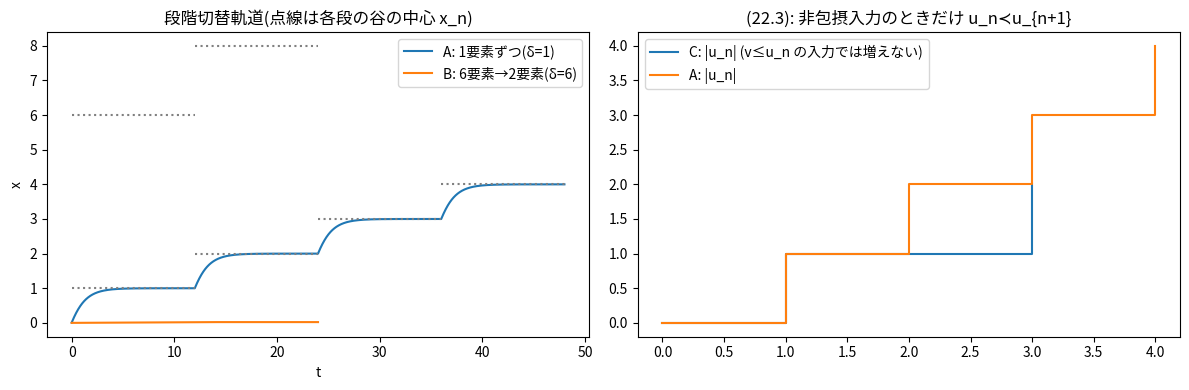

In [2]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for (us, cen, tr, ts), lab in [(casesA, "A: 1要素ずつ(δ=1)"), (casesB, "B: 6要素→2要素(δ=6)")]:
    ax[0].plot(np.arange(len(tr)) * dt, tr, label=lab)
    for k, c in enumerate(cen[1:]): ax[0].hlines(c, k * T_stage, (k + 1) * T_stage, ls=":", colors="gray")
ax[0].set_xlabel("t"); ax[0].set_ylabel("x"); ax[0].legend(); ax[0].set_title("段階切替軌道(点線は各段の谷の中心 x_n)")
ax[1].step(range(len(casesC[1])), casesC[1], where="post", label="C: |u_n| (v≤u_n の入力では増えない)")
ax[1].step(range(len(casesA[1])), casesA[1], where="post", label="A: |u_n|"); ax[1].legend(); ax[1].set_title("(22.3): 非包摂入力のときだけ u_n≺u_{n+1}")
plt.tight_layout(); plt.show()

### 左：段階切替軌道（点線は各段の谷の中心 $x_n$）

横軸は時間 $t$、縦軸は位置 $x$。灰色の点線が各段の谷の中心です（各段 12 秒ずつ）。

* **青（A）：** 最初の 12 秒で $x=0\to1$（段1の谷の中心 1）に **約 5 秒で到達** して水平になり、12 秒で段2に切り替わると $x=1\to2$、さらに $3$、$4$ と、**階段状に登ります**。各段の終端で谷の中心にほぼ一致しています（最終 $x=4.0$）。
* **橙（B）：** 段1の谷の中心は **6**（点線は上のほう）、出発点 $x=0$ は **6 から遠く**、**ほとんど動きません**（24 秒たっても $x\approx0.02$）。段2の中心は 8 でさらに遠く、やはり動けません。
  理由：ガウス谷は中心から遠いと勾配が極端に小さい。$\delta=6$ のとき勾配は約 $\dfrac{A\delta}{\sigma^2}e^{-\delta^2/(2\sigma^2)}=\dfrac{2\cdot6}{2.25}e^{-8}\approx1.8\times10^{-3}$ で、12 秒で動けるのは約 $0.02$ に過ぎません（図の約 $0.022$ と一致します）。

### 右：(22.3) 非包摂入力のときだけ $u_n\prec u_{n+1}$

縦軸は $\lvert u_n\rvert$（世界の要素数）、横軸は段 $n$。

* **橙（A）：** $0\to1\to2\to3\to4$。毎回新しい概念が入るので、**毎段、厳密に増えます**。
* **青（C）：** 入力が $\{0\},\{0\},\{0,1\}$。2番目の入力 $\{0\}$ は **すでに $u_1=\{0\}$ に含まれている** ので、世界は変わらず（要素数 $1\to1$）、3番目の $\{0,1\}$ で初めて $1\to2$。**含まれている入力では世界は上がりません。**

## 5. 数値確認

In [3]:
# %% 数値確認
usA, cenA, trA, tsA = casesA
usB, cenB, trB, tsB = casesB
print("A: 各段末の x =", [round(trA[i - 1], 3) for i in tsA[1:]], " 谷中心 =", cenA[1:])
print("B: 各段末の x =", [round(trB[i - 1], 3) for i in tsB[1:]], " 谷中心 =", cenB[1:])
assert all(abs(trA[i - 1] - c) < 0.05 for i, c in zip(tsA[1:], cenA[1:]))        # A: 各谷に到達
assert abs(trB[tsB[1] - 1] - cenB[1]) > 2.5                                     # B: 次の谷に入れない
assert casesC[1] == [0, 1, 1, 2] and casesA[1] == [0, 1, 2, 3, 4]               # (22.3)

A: 各段末の x = [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]  谷中心 = [1, 2, 3, 4]
B: 各段末の x = [np.float64(0.022), np.float64(0.022)]  谷中心 = [6, 8]


* A：各段の終端での $x$ は $[1.0,\ 2.0,\ 3.0,\ 4.0]$、谷の中心 $[1,2,3,4]$ と一致（`assert`：差 $<0.05$）。
* B：各段の終端での $x$ は $[0.022,\ 0.022]$、谷の中心 $[6,8]$ から遠い（`assert`：差 $>2.5$）。
* C：$\lvert u_n\rvert=[0,1,1,2]$、A：$[0,1,2,3,4]$。(22.3) の通り。

## 6. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **「消さずに包む」。** 原文は、上への更新は「古い自分を消す」のではなく「古い自分ごと包む」——それが $\vee$ である、と述べます。右の図で、世界の要素数は **決して減りません**。
* **悟りの階梯は上へ開いている。** 有限の段数で空に届くことは証明されません。「はしごの極限 $u_\infty\preceq\top$」という言い方がそれです。
* **ケース B の読み方の一例。** 新しい世界（谷）が **遠すぎる**（今の心の状態から見て、新しい谷がほとんど感じられない）と、時間をかけても動けません。「新しい視点を得たが、まだ心がそこに届かない」という状況を、数値で見せたものです。ステップを小さく（$\delta=1$）取れば登れます。ただしこれは **可到達性という明示仮定** の例であって、段の高さを上げるための処方箋を証明したものではありません。
* **同じ数学が、武器にも盾にもなる。** 原文の整合性確認④の言い方です。更新則 $\vee$ を知る者は、消されずに包み返せます。

## 7. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem22_LubStaircase.lean` ＋ `Tomabechi/Examples/Gaussian.lean` ＋ `Tomabechi/Examples/Theorem22_GaussianStages.lean`。

| | 内容 | 状態 |
| --- | --- | --- |
| 束の (22.1)(22.3) | 結合による更新と、非包摂なら厳密上昇 | 証明済 |
| ガウス谷の局所強凸 | $A=2,\ \sigma=\tfrac32$。半径 $\tfrac54$ の局所球で曲率 $\tilde V''\ge\tfrac18$ | 証明済 |
| **ケース A・C の実際の切替軌道**（連続時間） | A の中心列 $1,2,3,4,4,\dots$、C の中心列 $1,1,2,2,\dots$。各段を 12 秒ずつ流す ODE 解を時間順につないだ連続な軌道を構成。段内の部分準位での一意性、中心からの距離の単調減少、指数評価 (22.4)（率 $\tfrac12$）、待ち時間条件 (22.5)（$2\log9\le12$）、**各段の 12 秒後の誤差 $\le\tfrac18$**（前段の終点が次段の局所球に入ることを含む） | 証明済 |
| **ケース B** | 初期値 0 から中心 6 へ向かう大域解が存在し、12 秒後も次の中心 8 の局所球（半径 $\tfrac54$）の**外**（局所強凸の谷に入れない） | 証明済 |
| Python の **Euler 離散列と数値出力** | 連続時間の厳密軌道を証明したのであって、離散列そのものは証明していない | **未証明** |
| 一般の段階条件から任意のモデルを導くこと、23-B 一般核への接続 | このガウスモデルの具体的な結果のみ | **未証明** |

* **ケース B は定理22の反例ではありません。** 明示仮定（可到達性）が破れた場合の挙動です。
* もとの Python を $\sigma=1\to\tfrac32$、$B$ の入力を6要素→2要素に変更しました（Lean で局所球の成否を厳密に示すため）。